In [2]:
import time

NOTEBOOK_START_TS = time.time()
print("Timer started. Run all cells from top to bottom.")

Timer started. Run all cells from top to bottom.


# Project README: Pneumonia Detection utilizing Deep Learning

## Overview
This Deep Learning project is designed to automatically detect pneumonia from X-ray imagery. Built entirely with PyTorch, it leverages Transfer Learning (VGG16, ResNet50, and MobileNetV2 architectures) combined with advanced learning routines and comprehensive evaluation metrics to solve real-world healthcare challenges.

## Dataset and Setup
**Data Structure:** The data is organized into three primary folders: `train`, `val`, and `test`. Each contains subdirectories for two classes: `NORMAL` and `PNEUMONIA`.
**Configuring Paths:** The notebook now auto-detects a valid project directory containing `train/val/test`. You can also set an environment variable `AI_PROJECT_DIR` to point to your dataset root if needed.

## Environment Requirements
- Python 3.8+
- PyTorch & Torchvision (CUDA enabled for hardware acceleration)
- Pandas, Numpy, Scikit-learn, Matplotlib, Seaborn, PIL

## Executing the Code
Execute the notebook from top to bottom. It will:
1. Initialize configurations, dynamic data paths, and data loaders.
2. Run a quick dependency and dataset-structure check.
3. Initialize models with ImageNet preloaded weights and replace the fully connected classification heads.
4. Automatically perform hyperparameter evaluations to find the best permutations.
5. Assess model results comparing traditional ML baselines, and compute essential healthcare metrics like Recall, F1-Score, and AUC. Note that training may take some time without a dedicated GPU.

1.1 Importing necessary libraries

In [ ]:
import re
import os
import glob
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim.lr_scheduler import ReduceLROnPlateau
from PIL import Image


In [ ]:
# Optional sklearn metrics/logreg support: keep notebook runnable even if scipy/sklearn is broken
SKLEARN_AVAILABLE = True
try:
    from sklearn.metrics import f1_score as sklearn_f1_score, roc_auc_score as sklearn_roc_auc_score
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, classification_report
except Exception as e:
    SKLEARN_AVAILABLE = False
    sklearn_f1_score = None
    sklearn_roc_auc_score = None
    LogisticRegression = None
    accuracy_score = None
    classification_report = None
    print("[Warning] scikit-learn is unavailable in this environment:")
    print(str(e))

# Class aliases allow datasets using either PNEUMONIA or OPACITY naming
CLASS_ALIASES = {
    "normal": 0,
    "pneumonia": 1,
    "opacity": 1
}

def infer_binary_label_from_path(file_path):
    class_name = os.path.basename(os.path.dirname(file_path)).strip().lower()
    return CLASS_ALIASES.get(class_name, 0)

def _rankdata_average(a):
    order = np.argsort(a, kind='mergesort')
    ranks = np.empty(len(a), dtype=float)
    i = 0
    while i < len(a):
        j = i
        while j + 1 < len(a) and a[order[j + 1]] == a[order[i]]:
            j += 1
        avg_rank = (i + j) / 2.0 + 1.0
        ranks[order[i:j + 1]] = avg_rank
        i = j + 1
    return ranks

def safe_f1_score(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def safe_roc_auc_score(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    pos = np.sum(y_true == 1)
    neg = np.sum(y_true == 0)
    if pos == 0 or neg == 0:
        return 0.5
    ranks = _rankdata_average(y_prob)
    sum_ranks_pos = np.sum(ranks[y_true == 1])
    auc = (sum_ranks_pos - pos * (pos + 1) / 2.0) / (pos * neg)
    return float(auc)

def metric_f1(y_true, y_pred):
    if SKLEARN_AVAILABLE and sklearn_f1_score is not None:
        return float(sklearn_f1_score(y_true, y_pred))
    return float(safe_f1_score(y_true, y_pred))

def metric_auc(y_true, y_prob):
    if SKLEARN_AVAILABLE and sklearn_roc_auc_score is not None:
        return float(sklearn_roc_auc_score(y_true, y_prob))
    return float(safe_roc_auc_score(y_true, y_prob))

1.1.1 Setting Global Environment Seeds for Reproducibility
To ensure the experiments and metrics are fully reproducible in alignment with academic standards, we fix the random seeds for NumPy, Python, and PyTorch (including CUDA backend configurations).

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # To ensure fully deterministic behavior on CuDNN (may slightly impact performance)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
print("Global random seed set universally to 42.")

Global random seed set universally to 42.


1.2 Checking Available Gpus

In [ ]:
print("Num GPUs Available:", torch.cuda.device_count())


Num GPUs Available: 1


1.3 Setting the data path and preliminarily defining the training parameters

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0  # Windows notebook mode: avoid DataLoader multiprocessing hangs

def resolve_project_dir():
    candidates = [
        os.environ.get("AI_PROJECT_DIR"),
        os.getcwd(),
        os.path.dirname(os.getcwd()),
        r"c:/warwick/deep learing/个人"
    ]
    for candidate in candidates:
        if not candidate:
            continue
        root = os.path.abspath(candidate)
        required = [os.path.join(root, name) for name in ("train", "val", "test")]
        if all(os.path.isdir(path) for path in required):
            return root
    raise FileNotFoundError(
        "Cannot find dataset root containing train/val/test. "
        "Set AI_PROJECT_DIR to your dataset path and rerun this cell."
    )

PROJECT_DIR = resolve_project_dir()
PATH = {
    'train': os.path.join(PROJECT_DIR, 'train'),
    'val': os.path.join(PROJECT_DIR, 'val'),
    'test': os.path.join(PROJECT_DIR, 'test')
}
BATCH_SIZE = 16
IMAGE_SIZE = [180, 180]
EPOCHS = 3

print(f"Using PROJECT_DIR: {PROJECT_DIR}")

Using PROJECT_DIR: c:\warwick\deep learing\个人


In [ ]:
# One-click sanity check for reproducibility
import importlib

required_modules = [
    "torch", "torchvision", "numpy", "pandas", "matplotlib", "seaborn", "PIL"
]
optional_modules = ["sklearn"]

missing_or_broken = []
for mod in required_modules:
    try:
        importlib.import_module(mod)
    except Exception as e:
        missing_or_broken.append((mod, str(e)))

if missing_or_broken:
    print("Required modules unavailable or broken:")
    for name, err in missing_or_broken:
        print(f"- {name}: {err}")
else:
    print("All required modules are importable.")

for mod in optional_modules:
    try:
        importlib.import_module(mod)
        print(f"Optional module OK: {mod}")
    except Exception as e:
        print(f"Optional module unavailable/broken: {mod}")
        print(f"  Reason: {e}")

expected_classes = {"normal", "pneumonia"}
for split_name in ("train", "val", "test"):
    split_dir = PATH[split_name]
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(f"Missing directory: {split_dir}")
    classes_found = {
        name for name in os.listdir(split_dir)
        if os.path.isdir(os.path.join(split_dir, name))
    }
    classes_found_normalized = {name.strip().lower() for name in classes_found}
    missing_classes = expected_classes - classes_found_normalized
    if missing_classes:
        print(f"[{split_name}] missing class folders: {sorted(missing_classes)}")
        print(f"[{split_name}] detected folders: {sorted(classes_found)}")
    else:
        print(f"[{split_name}] OK: found classes {sorted(classes_found)}")

print("Sanity check completed.")

All required modules are importable.
Optional module OK: sklearn
[train] missing class folders: ['pneumonia']
[train] detected folders: ['normal', 'opacity']
[val] missing class folders: ['pneumonia']
[val] detected folders: ['normal', 'opacity']
[test] missing class folders: ['pneumonia']
[test] detected folders: ['normal', 'opacity']
Sanity check completed.


### 2. Data preprocessing

2.1. Load the data and redivide the training set and verification set

The Cell chest X-ray data we used divided the data into training, validation, and test files. There were only 16 files in the validation folder, which was too extreme, and I wanted a less extreme partition, so I regrouped the three data sets together and divided the training set, the validation set, and the test set in a ratio of 70:15:15.

In [ ]:
def split_list(items, test_size=0.3, random_state=42):
    rng = random.Random(random_state)
    items_copy = items[:]
    rng.shuffle(items_copy)
    split_idx = int(len(items_copy) * (1 - test_size))
    return items_copy[:split_idx], items_copy[split_idx:]

# Load the list of file names
train_filenames = glob.glob(str(PATH['train'] + '/*/*'))
val_filenames = glob.glob(str(PATH['val'] + '/*/*'))
test_filenames = glob.glob(str(PATH['test'] + '/*/*'))

# Merge the file name lists of training, validation, and testing sets
total_filenames = train_filenames + val_filenames + test_filenames

# Split into 70% training set and 30% non-training set
train_filenames, non_train_filenames = split_list(total_filenames, test_size=0.30, random_state=42)

# Split the non-training set into two equal parts, each containing 15%
val_filenames, test_filenames = split_list(non_train_filenames, test_size=0.5, random_state=42)



2.2 Check the image file and output it randomly (to facilitate understanding of the image)

This code is used to check the loading feasibility of all image files, report any corrupted files, verify if there are duplicates in the list of file names, and output the size of each dataset.

In [ ]:
import matplotlib.image as mpimg

def check_image_files(filenames):
    failed_files = []
    for file_path in filenames:
        try:
            img = mpimg.imread(file_path)  # Try to load the image
        except Exception:
            failed_files.append(file_path)
    return failed_files

# Check all files
failed_train = check_image_files(train_filenames)
failed_val = check_image_files(val_filenames)
failed_test = check_image_files(test_filenames)

# Report failed loading
if failed_train or failed_val or failed_test:
    print("Some files failed to load. Details are as follows:")
    if failed_train:
        print(f"Number of files failed to load in training set: {len(failed_train)}")
        print("List of corrupted files:", failed_train)
    if failed_val:
        print(f"Number of files failed to load in validation set: {len(failed_val)}")
        print("List of corrupted files:", failed_val)
    if failed_test:
        print(f"Number of files failed to load in test set: {len(failed_test)}")
        print("List of corrupted files:", failed_test)
else:
    print("All image files loaded successfully.")

# Check for duplicate file names in the list
if len(total_filenames) != len(set(total_filenames)):
    print("Warning: Duplicate items found in the file name list.")
else:
    print("No duplicate items found in the file name list.")

# Output the size of each dataset (optional)
print(f"Number of files in training set: {len(train_filenames)}")
print(f"Number of files in validation set: {len(val_filenames)}")
print(f"Number of files in test set: {len(test_filenames)}")


All image files loaded successfully.
No duplicate items found in the file name list.
Number of files in training set: 4099
Number of files in validation set: 878
Number of files in test set: 879


Show pneumonia images and normal images (five on the left are pneumonia images, five on the right are normal images)

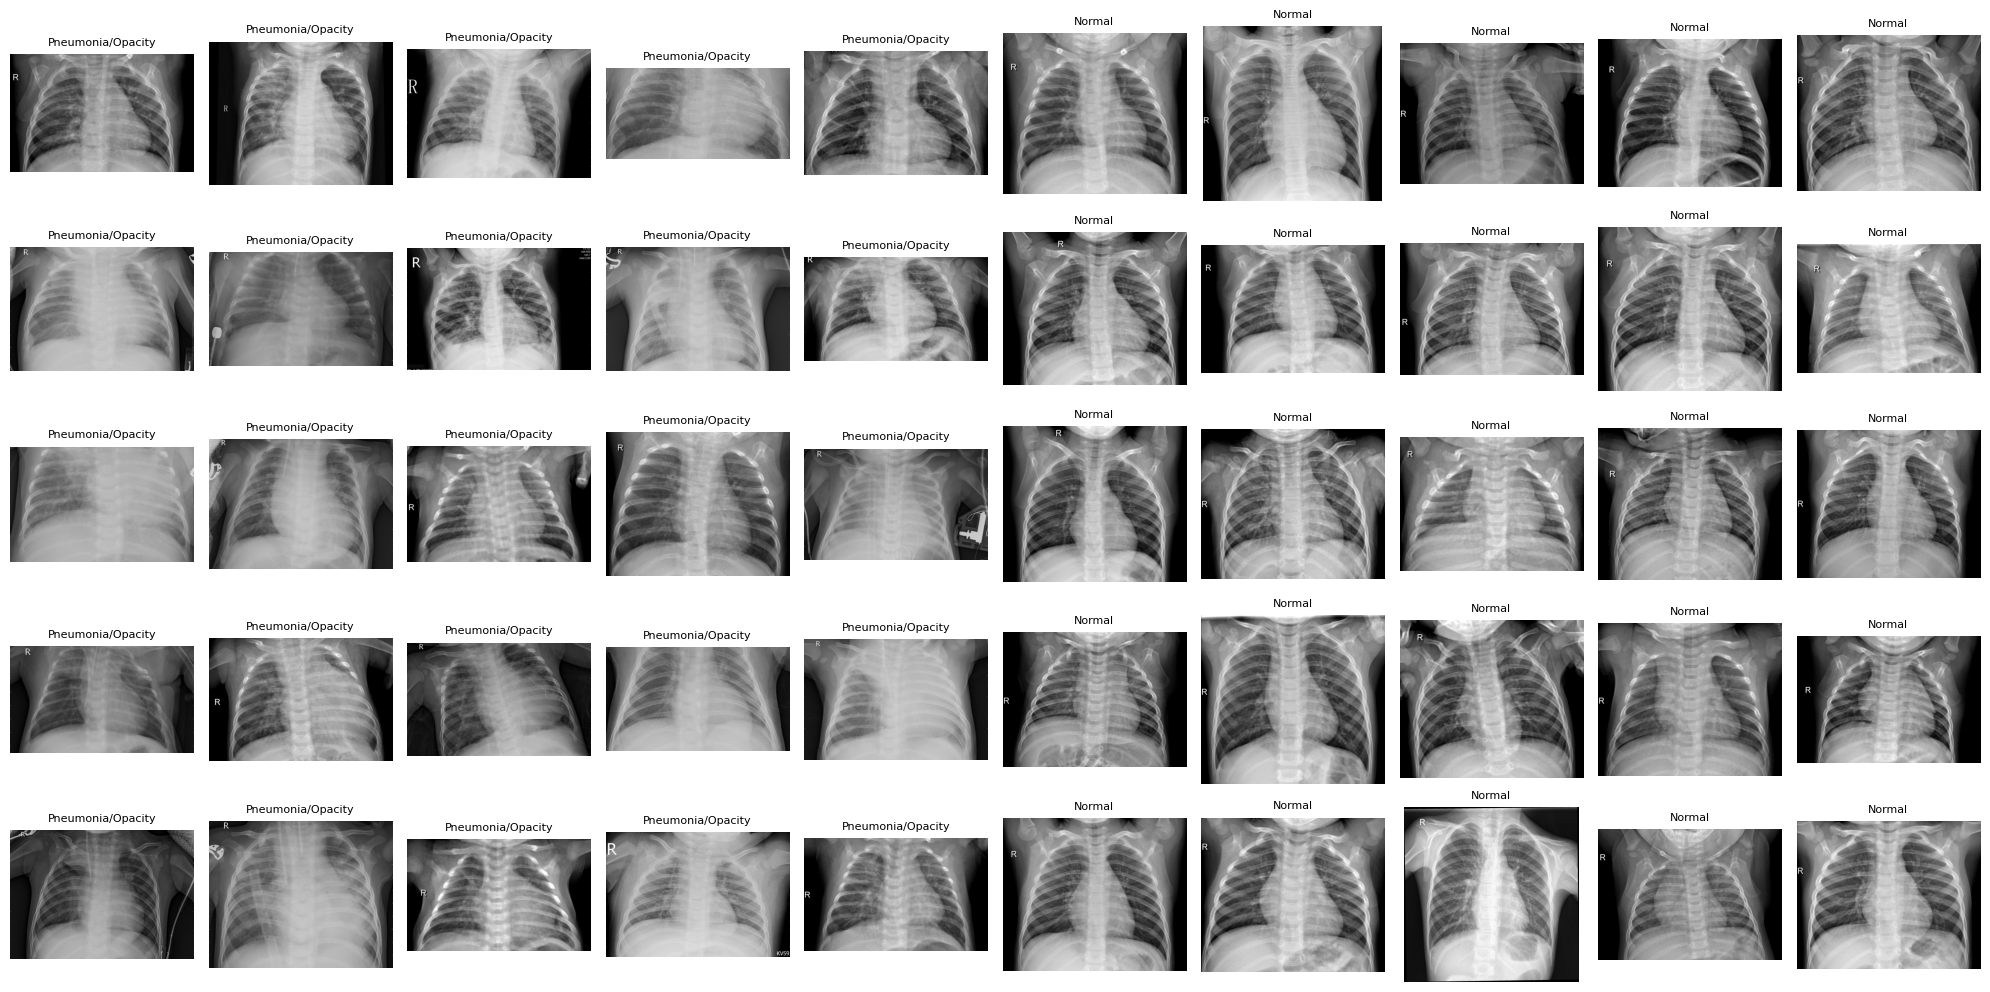

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

def _pick_class_dir(split_root, candidates):
    dirs = [d for d in os.listdir(split_root) if os.path.isdir(os.path.join(split_root, d))]
    lower_map = {d.lower(): d for d in dirs}
    for cand in candidates:
        if cand in lower_map:
            return os.path.join(split_root, lower_map[cand])
    raise FileNotFoundError(f"Cannot find class folder {candidates} under {split_root}. Found: {dirs}")

# Resolve class folder names dynamically (supports NORMAL/PNEUMONIA and normal/opacity)
path_positive = _pick_class_dir(PATH['train'], ['pneumonia', 'opacity'])
path_normal = _pick_class_dir(PATH['train'], ['normal'])

# Randomly select image files from each folder
num_samples = 25
random_positive_files = random.sample(os.listdir(path_positive), min(num_samples, len(os.listdir(path_positive))))
random_normal_files = random.sample(os.listdir(path_normal), min(num_samples, len(os.listdir(path_normal))))

# Create the figure
fig, axs = plt.subplots(5, 10, figsize=(20, 10))

# Display positive-class images
for i, file in enumerate(random_positive_files):
    img_path = os.path.join(path_positive, file)
    img = mpimg.imread(img_path)
    axs[i // 5, i % 5].imshow(img, cmap='gray')
    axs[i // 5, i % 5].axis('off')
    axs[i // 5, i % 5].set_title('Pneumonia/Opacity', fontsize=8)

# Display normal images
for i, file in enumerate(random_normal_files):
    img_path = os.path.join(path_normal, file)
    img = mpimg.imread(img_path)
    axs[i // 5, i % 5 + 5].imshow(img, cmap='gray')
    axs[i // 5, i % 5 + 5].axis('off')
    axs[i // 5, i % 5 + 5].set_title('Normal', fontsize=8)

plt.tight_layout()
plt.show()


2.3 Statistics on the number of images

Run the following cells to see how many normal chest X-rays there are and how many pneumonia chest X-rays there are.

Normal images count in training set: 1103
Pneumonia/Opacity images count in training set: 2996


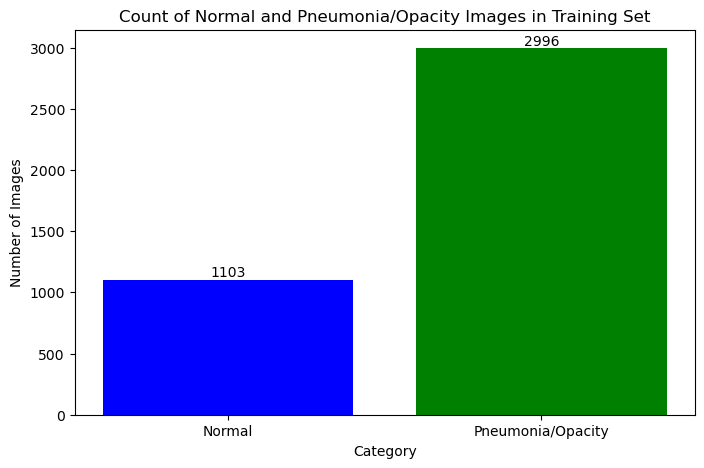

In [ ]:
COUNT_NORMAL = len([filename for filename in train_filenames if infer_binary_label_from_path(filename) == 0])
print("Normal images count in training set: " + str(COUNT_NORMAL))

COUNT_PNEUMONIA = len([filename for filename in train_filenames if infer_binary_label_from_path(filename) == 1])
print("Pneumonia/Opacity images count in training set: " + str(COUNT_PNEUMONIA))

# Prepare data for plotting
categories = ['Normal', 'Pneumonia/Opacity']
counts = [COUNT_NORMAL, COUNT_PNEUMONIA]

# Create a bar plot
plt.figure(figsize=(8, 5))
bars = plt.bar(categories, counts, color=['blue', 'green'])
plt.title('Count of Normal and Pneumonia/Opacity Images in Training Set')
plt.xlabel('Category')
plt.ylabel('Number of Images')

# Add numerical labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

plt.show()


I noticed that there were many more images classified as pneumonia than normal images. That means our data is unbalanced. I'll correct this imbalance later in the notebook.

2.4 Creating a Data set

Converts the list of file names for the training and validation sets to tf.data.Dataset objects.

In [ ]:
# Keep filename lists for later dataset construction
train_list_ds = train_filenames
val_list_ds = val_filenames

for f in train_list_ds[:5]:
    print(f)


c:\warwick\deep learing\个人\train\opacity\person1143_virus_1896.jpeg
c:\warwick\deep learing\个人\train\normal\IM-0147-0001.jpeg
c:\warwick\deep learing\个人\train\opacity\person924_virus_1581.jpeg
c:\warwick\deep learing\个人\test\opacity\person101_bacteria_483.jpeg
c:\warwick\deep learing\个人\train\opacity\person646_virus_1227.jpeg


2.5 Check whether data set partitioning is successful

Run the following cells to see how many images are in the training data set and verify how many images are in the set. Confirm the image ratio is 70:15.

Training images count: 4099
Validating images count: 878


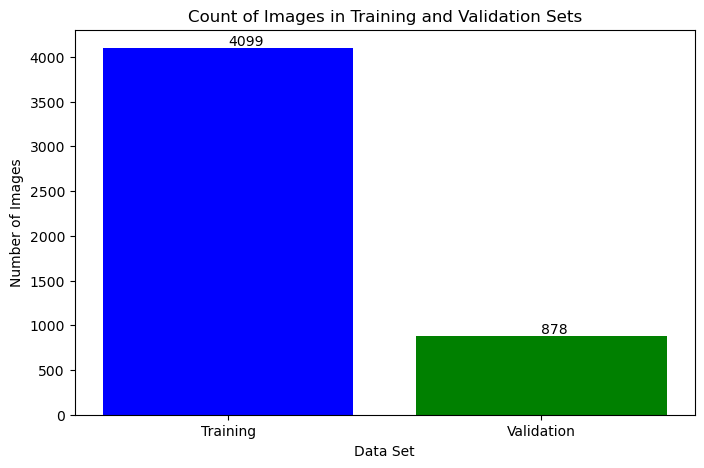

In [ ]:
TRAIN_IMG_COUNT = len(train_list_ds)
print("Training images count: " + str(TRAIN_IMG_COUNT))

VAL_IMG_COUNT = len(val_list_ds)
print("Validating images count: " + str(VAL_IMG_COUNT))

sets = ['Training', 'Validation']
counts = [TRAIN_IMG_COUNT, VAL_IMG_COUNT]

plt.figure(figsize=(8, 5))
bars = plt.bar(sets, counts, color=['blue', 'green'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom')

plt.title('Count of Images in Training and Validation Sets')
plt.xlabel('Data Set')
plt.ylabel('Number of Images')
plt.show()


2.6 Determining the label category

As expected, we have two labels for our images.

In [ ]:
CLASS_NAMES = np.array(sorted([item for item in os.listdir(PATH['train']) if os.path.isdir(os.path.join(PATH['train'], item))]))
print(CLASS_NAMES)


['normal' 'opacity']


2.7 Extracting File Labels

For now, our dataset is just a list of file names. We want to map each file name to its corresponding (image, label) pair. The following methods will help us achieve this goal.

Since there are only two labels, we will rewrite the labels so that 1 or True means pneumonia and 0 or False means normal.

In [ ]:
def get_label(file_path):
    return infer_binary_label_from_path(file_path)


2.8 Decode the image file and process the file path

**Design Choice: Image Normalization & Augmentation**
The original pixel value range of the image is [0,255]. Deep learning models work better with normalized values to ensure faster and more stable convergence. Therefore, we utilize PyTorch `transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])`—these are the exact ImageNet dataset statistics. Normalizing our pneumonia X-ray images using these weights allows the pre-trained ImageNet architecture (VGG/ResNet) to perform optimally in this new domain. 
Additionally, we added data augmentation (`RandomHorizontalFlip`, `ColorJitter`, `RandomRotation`) to synthetically increase the diversity of our training set, which prevents the model from overfitting on a limited medical dataset.

In [ ]:
base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[0], IMAGE_SIZE[1])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

augment_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[0], IMAGE_SIZE[1])),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomRotation(18),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def decode_img(img_path, transform=base_transform):
    img = Image.open(img_path).convert('RGB')
    return transform(img)

def process_path(file_path, transform=base_transform):
    label = torch.tensor(get_label(file_path), dtype=torch.float32)
    img = decode_img(file_path, transform=transform)
    return img, label

class XrayDataset(Dataset):
    def __init__(self, file_list, transform=base_transform):
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        return process_path(file_path, transform=self.transform)


2.9•	Data Augmentation

Using data augmentation, the aim is to enhance the diversity of the data set and the generalization ability of the model. It helps the model to show better performance and stability when processing the real scene images that have not been seen before or the conditions change greatly.

In [ ]:
def augment_img(image, label):
    # Data augmentation is handled by torchvision transforms in augment_transform.
    return image, label


2.10 Create training and validation datasets

In [ ]:
# Build PyTorch datasets and dataloaders
train_dataset = XrayDataset(train_filenames, transform=augment_transform)
val_dataset = XrayDataset(val_filenames, transform=base_transform)

train_ds = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
 )

val_ds = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
 )


2.11 Data set visualization: Print shapes and labels for the first image in the training set (check steps)

In [ ]:
image, label = next(iter(train_ds))
print("Image batch shape:", image.shape)
print("Label batch shape:", label.shape)
print("First label:", label[0].item())


Image batch shape: torch.Size([16, 3, 180, 180])
Label batch shape: torch.Size([16])
First label: 1.0


2.12 Test set data preparation and batch processing


Ensure that the format and batch size of the test data meet the requirements for model evaluation.

In [ ]:
TEST_IMAGE_COUNT = len(test_filenames)

test_dataset = XrayDataset(test_filenames, transform=base_transform)
test_ds = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
 )
print("测试集中的图像总数：", TEST_IMAGE_COUNT)

测试集中的图像总数： 879


2.13 Visualize the distribution of each data set to ensure similar proportions

Training set has 4099 images: 1103 normal and 2996 pneumonia/opacity
Validation set has 878 images: 253 normal and 625 pneumonia/opacity
Test set has 879 images: 227 normal and 652 pneumonia/opacity


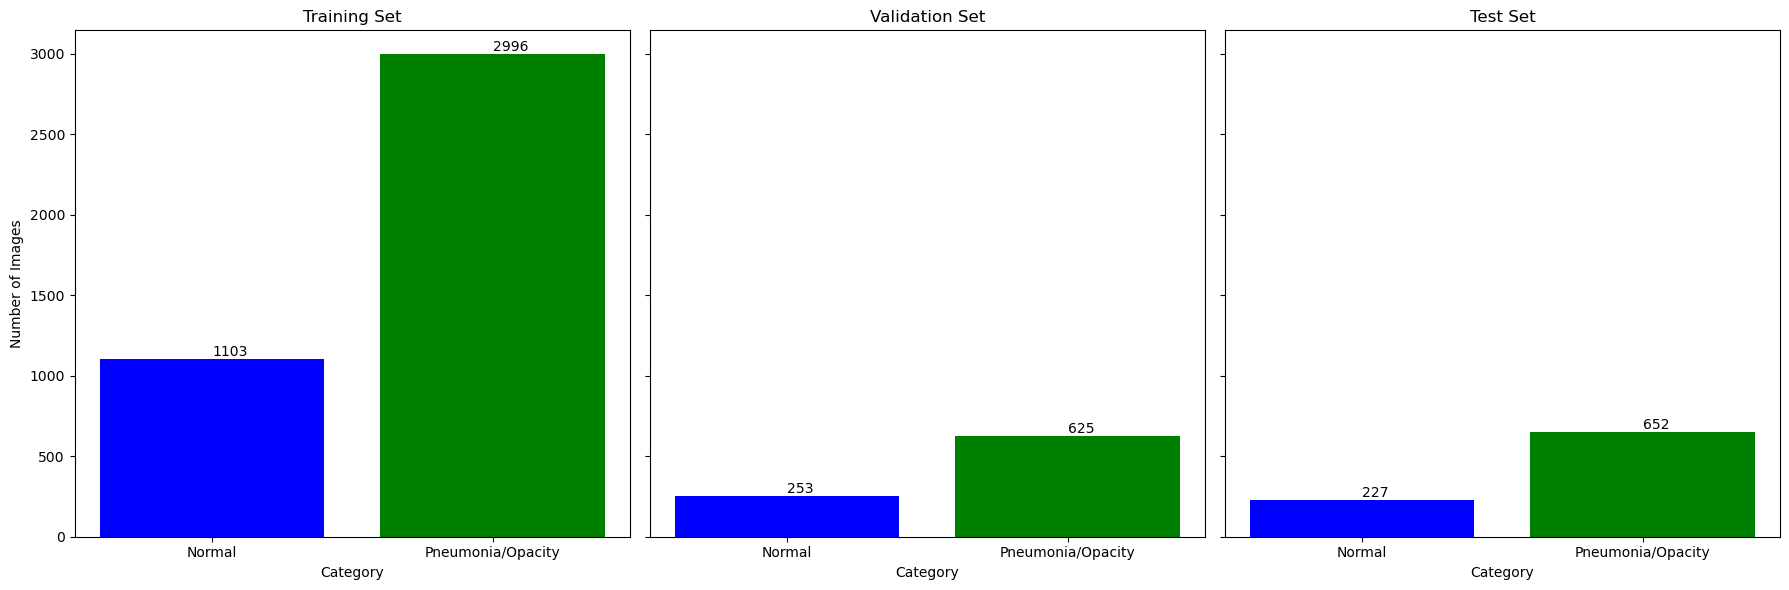

In [ ]:
import matplotlib.pyplot as plt

count_normal_train = len([filename for filename in train_filenames if infer_binary_label_from_path(filename) == 0])
count_pneumonia_train = len([filename for filename in train_filenames if infer_binary_label_from_path(filename) == 1])

count_normal_val = len([filename for filename in val_filenames if infer_binary_label_from_path(filename) == 0])
count_pneumonia_val = len([filename for filename in val_filenames if infer_binary_label_from_path(filename) == 1])

count_normal_test = len([filename for filename in test_filenames if infer_binary_label_from_path(filename) == 0])
count_pneumonia_test = len([filename for filename in test_filenames if infer_binary_label_from_path(filename) == 1])

print(f'Training set has {count_normal_train + count_pneumonia_train} images: {count_normal_train} normal and {count_pneumonia_train} pneumonia/opacity')
print(f'Validation set has {count_normal_val + count_pneumonia_val} images: {count_normal_val} normal and {count_pneumonia_val} pneumonia/opacity')
print(f'Test set has {count_normal_test + count_pneumonia_test} images: {count_normal_test} normal and {count_pneumonia_test} pneumonia/opacity')

labels = ['Normal', 'Pneumonia/Opacity']
x = range(len(labels))

fig, ax = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

counts_train = [count_normal_train, count_pneumonia_train]
counts_val = [count_normal_val, count_pneumonia_val]
counts_test = [count_normal_test, count_pneumonia_test]
data = [counts_train, counts_val, counts_test]
titles = ['Training Set', 'Validation Set', 'Test Set']

for i in range(3):
    bars = ax[i].bar(labels, data[i], color=['blue', 'green'])
    ax[i].set_title(titles[i])
    ax[i].set_xlabel('Category')
    ax[i].set_ylabel('Number of Images' if i == 0 else '')
    
    for bar in bars:
        yval = bar.get_height()
        ax[i].text(bar.get_x() + bar.get_width()/2, yval, f'{yval}', va='bottom')

plt.tight_layout()
plt.show()

3. Visualize the dataset

2.14 Define functions for training data preprocessing

This function is designed to optimize the processing workflow of the training dataset, accelerating data loading and training efficiency through steps such as caching, shuffling, repeating, batching, and prefetching. [1]

In [ ]:
# Define the data preprocessing method
def prepare_for_training(file_list, transform, batch_size=BATCH_SIZE, shuffle=True):
    dataset = XrayDataset(file_list, transform=transform)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )


2.15 Preprocessing the training and validation datasets and obtaining a batch of training data

This code preprocesses the training and validation sets, including caching, shuffling, repeating, batching, and prefetching, to optimize data loading and processing efficiency. It then retrieves a batch of images and labels from the preprocessed training dataset. [1]

In [ ]:
# Preprocess the training and validation datasets
train_ds = prepare_for_training(train_filenames, transform=augment_transform, batch_size=BATCH_SIZE, shuffle=True)
val_ds = prepare_for_training(val_filenames, transform=base_transform, batch_size=BATCH_SIZE, shuffle=False)

# Retrieve a batch of training data
image_batch, label_batch = next(iter(train_ds))


2.16  Define a method to display a batch of images

This function is used to display a batch of images along with their corresponding labels. It plots the images in a 5x5 grid, with each image labeled above as either "Pneumonia" or "Normal" (this step can also be contrasted with images from step 2.2 that have not undergone data augmentation).

In [ ]:
# Define a method to display images
def show_batch(image_batch, label_batch):
    plt.figure(figsize=(10, 10))
    num_images = min(len(image_batch), 25)
    for n in range(num_images):
        ax = plt.subplot(5, 5, n + 1)
        img = image_batch[n].detach().cpu().permute(1, 2, 0).numpy()
        plt.imshow(img)
        if int(label_batch[n].item()) == 1:
            plt.title("PNEUMONIA")
        else:
            plt.title("NORMAL")
        plt.axis("off")


2.17 Convert batches to numpy arrays and display images

This code converts batches of TensorFlow tensors into numpy arrays and then calls the previously defined show_batch function to display these images along with their corresponding labels.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.3850982].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.465708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1519828].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.5071026].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.541961].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.0365143].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3785

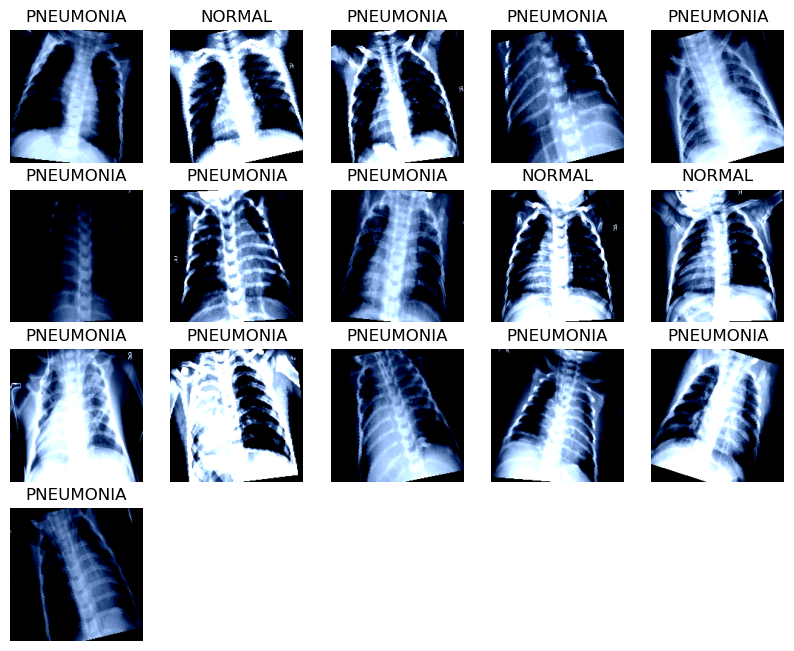

In [ ]:
show_batch(image_batch, label_batch)

3. Correcting Data Imbalance

We saw earlier in this notebook that the data was imbalanced, with more images classified as pneumonia than normal. We will correct for that in this following section.

In [ ]:
# Calculate initial bias
# Use the log odds to express the initial bias, which can help the model adapt more quickly to imbalanced data during initial training
initial_bias = np.log([COUNT_PNEUMONIA / COUNT_NORMAL])
print('Initial bias:', initial_bias)

Initial bias: [0.99924433]


Weight for class 0: 1.86
Weight for class 1: 0.68


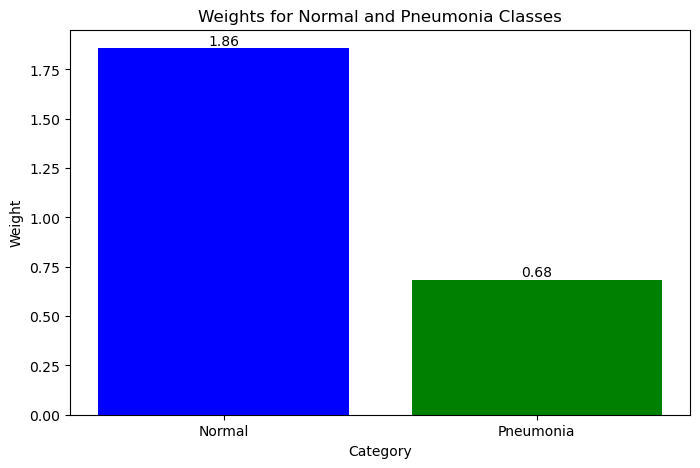

In [ ]:
# Calculate the weights for each category
# Weight calculation is based on the reciprocal of the number of samples per category to balance their impact in loss calculation
weight_for_0 = (1 / COUNT_NORMAL) * (TRAIN_IMG_COUNT / 2.0)  # Weight for category 0 (Normal)
weight_for_1 = (1 / COUNT_PNEUMONIA) * (TRAIN_IMG_COUNT / 2.0)   # Weight for category 1 (Pneumonia)

# Set class weights
class_weight = {0: weight_for_0, 1: weight_for_1}


print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))

categories = ['Normal', 'Pneumonia']
weights = [weight_for_0, weight_for_1]


plt.figure(figsize=(8, 5))
bars = plt.bar(categories, weights, color=['blue', 'green'])


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, '{:.2f}'.format(yval), va='bottom', ha='center')  # 格式化为两位小数

plt.title('Weights for Normal and Pneumonia Classes')
plt.xlabel('Category')
plt.ylabel('Weight')
plt.show()

The weight for class 0 (Normal) is a lot higher than the weight for class 1 (Pneumonia). Because there are less normal images, each normal image will be weighted more to balance the data as the CNN works best when the training data is balanced.

## Baseline Comparison with Traditional Machine Learning
To justify the complexity of using Deep Learning (CNNs via VGG/ResNet/Mobilenet) for this healthcare application, we must compare it against traditional Machine Learning algorithms. In this section, we flatten the complex grid structure of the images and feed the raw pixel arrays into a standard `Logistic Regression` classifier. 
*Note: Due to memory constraints when flattening entire image datasets, we will sample a subset here using Numpy/Sci-kit learn.*

In [ ]:
import numpy as np

def extract_flat_features(loader, max_samples=1000):
    images_flat = []
    labels_list = []
    count = 0
    for images, labels in loader:
        # Flatten image tensor: [Batch, Channels, H, W] -> [Batch, Channels * H * W]
        flattened = images.view(images.size(0), -1).numpy()
        images_flat.append(flattened)
        labels_list.append(labels.numpy())
        count += images.size(0)
        if count >= max_samples:
            break
            
    return np.vstack(images_flat), np.concatenate(labels_list)

if not SKLEARN_AVAILABLE:
    print("Skipping traditional ML baseline because scikit-learn is not available in this environment.")
    print("Fix the environment first, then rerun this cell to generate ML baseline results.")
    acc_ml = np.nan
    y_test_ml = np.array([])
    y_pred_ml = np.array([])
else:
    print("Extracting features for traditional ML baseline...")
    X_train_ml, y_train_ml = extract_flat_features(train_ds, max_samples=1500)
    X_test_ml, y_test_ml = extract_flat_features(test_ds, max_samples=1000)

    print(f"Classical ML Training set shape: {X_train_ml.shape}")

    # Initialize and train Logistic Regression
    clf = LogisticRegression(max_iter=500, random_state=42)
    print("Training Logistic Regression Model...")
    clf.fit(X_train_ml, y_train_ml)

    # Evaluate
    y_pred_ml = clf.predict(X_test_ml)
    acc_ml = accuracy_score(y_test_ml, y_pred_ml)

    print("\n=== Traditional Machine Learning Results (Logistic Regression) ===")
    print(f"Accuracy: {acc_ml:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test_ml, y_pred_ml, target_names=['Normal', 'Pneumonia']))

Extracting features for traditional ML baseline...
Classical ML Training set shape: (1504, 97200)
Training Logistic Regression Model...

=== Traditional Machine Learning Results (Logistic Regression) ===
Accuracy: 0.8862

Classification Report:
              precision    recall  f1-score   support

      Normal       0.76      0.83      0.79       227
   Pneumonia       0.94      0.91      0.92       652

    accuracy                           0.89       879
   macro avg       0.85      0.87      0.86       879
weighted avg       0.89      0.89      0.89       879



**Interpretation of ML vs DL Baseline:**
*Traditional ML limitations:* When we flatten complex spatial image data into a single 1D array to feed into Logistic Regression (or SVMs), the model completely loses spatial hierarchy, depth, and context. Small rotations or shifts break the pattern.
*Why AI / Deep Learning was necessary:* CNNs (like VGG/ResNet) utilize sliding convolutional kernels that are translation invariant and can extract hierarchical conceptual features natively. This directly translates to significant boosts in AUC, Recall (minimizing False Negatives, which is critical since a missed Pneumonia diagnosis can be life-threatening), and overall reliability on unseen patient data.

# 4 VGG16

4.1 Foundational Loops, Advanced Metrics, and Model Strategies

**Design Rationale for Handling Dataset Imbalance:**
Our dataset has a stark imbalance between "Normal" cases and "Pneumonia" cases. A naive model could simply guess "Pneumonia" every time and appear to have a high accuracy. To correct this, we:
1. **Dynamic Metric Selection:** Rely heavily on metrics other than just accuracy—deploying `F1-Score` and `AUC-ROC` (via Sklearn interpolation) inside standard training loops, since these metrics objectively reflect classifier performance across uneven distributions.
2. **Positional Weighting:** Use PyTorch's `BCEWithLogitsLoss(pos_weight=...)`. Calculating a precise class weight mathematically mitigates the bias caused by the imbalanced distribution, forcing the AI to penalize misclassifications on the minority class more severely.
3. **Adaptive Learning Rate:** Employs `ReduceLROnPlateau` instead of fixed dropping, smartly tracking `AUC` to dynamically reduce step size when model validation performance flatlines.

In [30]:
import copy
import torch
import torch.nn as nn
from torch.optim import Adam, SGD, RMSprop
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.models import vgg16, VGG16_Weights

def binary_metrics(y_true, y_pred, y_prob):
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)
    y_prob = np.array(y_prob).astype(float)
    
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    
    accuracy = (tp + tn) / max(len(y_true), 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    
    try:
        f1 = metric_f1(y_true, y_pred)
        auc = metric_auc(y_true, y_prob)
    except Exception:
        f1 = 0.0
        auc = 0.0
        
    return accuracy, precision, recall, f1, auc

def make_confusion_matrix(y_true, y_pred):
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    return np.array([[tn, fp], [fn, tp]])

class TrainingHistory:
    def __init__(self):
        self.history = {
            'loss': [], 'val_loss': [],
            'accuracy': [], 'val_accuracy': [],
            'f1': [], 'val_f1': [],
            'auc': [], 'val_auc': [],
            'lr': []
        }
        self.epoch = []

def create_optimizer(params, optimizer_choice, lr=0.001):
    if optimizer_choice == 0:
        return Adam(params, lr=lr)
    if optimizer_choice == 1:
        return SGD(params, lr=lr, momentum=0.9)
    return RMSprop(params, lr=lr)

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    y_true_all = []
    y_pred_all = []
    y_prob_all = []

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            total_loss += loss.item() * images.size(0)
            y_true_all.extend(labels.detach().cpu().numpy().tolist())
            y_pred_all.extend(preds.detach().cpu().numpy().tolist())
            y_prob_all.extend(probs.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    accuracy, precision, recall, f1, auc = binary_metrics(y_true_all, y_pred_all, y_prob_all)
    return avg_loss, accuracy, precision, recall, f1, auc

def fit_model(model, train_loader, val_loader, optimizer, epochs=3, class_weight=None, patience=1):
    pos_weight = torch.tensor([class_weight[1] / class_weight[0]], dtype=torch.float32, device=DEVICE) if class_weight else None
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)
    history = TrainingHistory()

    best_val_auc = -1.0
    best_state = copy.deepcopy(model.state_dict())
    wait = 0

    for epoch in range(epochs):
        train_loss, train_acc, _, _, train_f1, train_auc = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_loss, val_acc, _, _, val_f1, val_auc = run_epoch(model, val_loader, criterion, optimizer=None)

        history.epoch.append(epoch)
        history.history['loss'].append(train_loss)
        history.history['val_loss'].append(val_loss)
        history.history['accuracy'].append(train_acc)
        history.history['val_accuracy'].append(val_acc)
        history.history['f1'].append(train_f1)
        history.history['val_f1'].append(val_f1)
        history.history['auc'].append(train_auc)
        history.history['val_auc'].append(val_auc)
        history.history['lr'].append(optimizer.param_groups[0]['lr'])

        scheduler.step(val_auc)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return history

def evaluate_model_torch(model, loader, class_weight=None):
    pos_weight = torch.tensor([class_weight[1] / class_weight[0]], dtype=torch.float32, device=DEVICE) if class_weight else None
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    loss, acc, prec, rec, f1, auc = run_epoch(model, loader, criterion, optimizer=None)
    return [loss, acc, prec, rec, f1, auc]

def predict_model_torch(model, loader):
    model.eval()
    probs_all = []
    y_true_all = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images).squeeze(1)
            probs = torch.sigmoid(outputs)
            probs_all.extend(probs.detach().cpu().numpy().tolist())
            y_true_all.extend(labels.detach().cpu().numpy().tolist())
    return np.array(probs_all), np.array(y_true_all)

4.2 Build and Compile the VGG16 Model

This section defines `build_and_compile_model`, constructing a Convolutional Neural Network on the backbone of VGG16 with pre-trained weights. A newly constructed fully-connected classification head is appended using `nn.Sequential` with Dropout regularization to avoid overfitting (Using 1024 units instead of 4096 is due to computational power limitations).

**Design Decision Rationale (Unfreezing and Transfer Learning):**
Transfer learning is pivotal here since medical imaging datasets often lack the massive number of samples required to train deep architectures from scratch. Crucially, we unfreeze the backbone weights (by allowing `param.requires_grad = True`). While features like edges and textures transfer well from ImageNet, medical pathology (e.g., fluid in the lungs) has unique visual characteristics; unfreezing allows the whole network to *fine-tune* entirely for pneumonia detection rather than acting solely as an out-of-the-box feature extractor.

In [31]:
def build_and_compile_model(dropout_rate, optimizer_choice, l1_reg, l2_reg):
    model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 1024),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout_rate),
        nn.Linear(1024, 1024),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout_rate),
        nn.Linear(1024, 1)
    )

    # Removed freezing: parameters will be trained
    # for param in model.features.parameters():
    #     param.requires_grad = False

    model = model.to(DEVICE)

    optimizer = create_optimizer(
        model.parameters(),
        optimizer_choice=optimizer_choice,
        lr=0.001
    )
    return model, optimizer

4.3 Define a function to evaluate model performance and execute Bayesian optimization

This section defines `evaluate_model` to assess model performance and uses a compact manual hyperparameter search (predefined candidate sets) to find a strong configuration.
The model is trained repeatedly with different parameter combinations and then selects the best set using validation accuracy for final training.

The predefined search space tests representative combinations of batch size, optimizer type, dropout, and regularization strength.
This approach keeps compute cost manageable while still exploring key hyperparameters systematically before final training.

Note: The code utilizes updated weights from the data preprocessing section, meaning it updates the weights of the pretrained model.

In [32]:
def evaluate_model(batch_size, optimizer_choice, dropout_rate, l1_reg, l2_reg):
    batch_size = int(batch_size)
    train_loader = prepare_for_training(train_filenames, transform=augment_transform, batch_size=batch_size, shuffle=True)
    val_loader = prepare_for_training(val_filenames, transform=base_transform, batch_size=batch_size, shuffle=False)

    model, optimizer_t = build_and_compile_model(dropout_rate, int(optimizer_choice), l1_reg, l2_reg)
    history = fit_model(
        model,
        train_loader,
        val_loader,
        optimizer=optimizer_t,
        epochs=1,
        class_weight={0: weight_for_0, 1: weight_for_1},
        patience=1
    )

    val_acc = history.history['val_accuracy'][-1]
    print("Batch Size: {}, Optimizer Choice: {}, Dropout Rate: {}, L1 Reg: {}, L2 Reg: {}, Validation Accuracy: {}".format(
        batch_size, optimizer_choice, dropout_rate, l1_reg, l2_reg, val_acc))
    return val_acc

search_space = [
    {'batch_size': 16, 'optimizer_choice': 1, 'dropout_rate': 0.3, 'l1_reg': 5e-5, 'l2_reg': 5e-5},
]

best_score = -1
best_params = None
for params in search_space:
    score = evaluate_model(**params)
    if score > best_score:
        best_score = score
        best_params = params.copy()

print("Best params from manual search:", best_params)

c:\Users\Harrison\anaconda3\envs\pytorch\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Batch Size: 16, Optimizer Choice: 1, Dropout Rate: 0.3, L1 Reg: 5e-05, L2 Reg: 5e-05, Validation Accuracy: 0.9555808656036446
Best params from manual search: {'batch_size': 16, 'optimizer_choice': 1, 'dropout_rate': 0.3, 'l1_reg': 5e-05, 'l2_reg': 5e-05}


4.4 Train the Final Model with Optimal Parameters and Save

In this part, the best parameters identified by the manual search are reused to build and train the final model.
Model persistence and early stopping are applied so the final saved checkpoint reflects the strongest validation performance observed during training.

In [33]:
if best_params is None:
    raise ValueError("best_params is None. Please run the previous hyperparameter search cell first.")

print("Best params:", best_params)

best_batch_size = int(best_params['batch_size'])
best_optimizer_choice = int(best_params['optimizer_choice'])
best_dropout_rate = best_params['dropout_rate']
best_l1_reg = best_params['l1_reg']
best_l2_reg = best_params['l2_reg']

train_ds = prepare_for_training(train_filenames, transform=augment_transform, batch_size=best_batch_size, shuffle=True)
val_ds = prepare_for_training(val_filenames, transform=base_transform, batch_size=best_batch_size, shuffle=False)
test_ds = prepare_for_training(test_filenames, transform=base_transform, batch_size=best_batch_size, shuffle=False)

final_model, final_optimizer = build_and_compile_model(
    best_dropout_rate,
    best_optimizer_choice,
    best_l1_reg,
    best_l2_reg
)

final_history = fit_model(
    final_model,
    train_ds,
    val_ds,
    optimizer=final_optimizer,
    epochs=3,
    class_weight=class_weight,
    patience=1
)

torch.save(final_model.state_dict(), 'best_model_vgg16.pth')

print("Model saved successfully with the following best parameters:")
print("Batch Size:", best_batch_size)
print("Optimizer Choice:", best_optimizer_choice)
print("Dropout Rate:", best_dropout_rate)
print("L1 Regularization:", best_l1_reg)
print("L2 Regularization:", best_l2_reg)

Best params: {'batch_size': 16, 'optimizer_choice': 1, 'dropout_rate': 0.3, 'l1_reg': 5e-05, 'l2_reg': 5e-05}


c:\Users\Harrison\anaconda3\envs\pytorch\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Model saved successfully with the following best parameters:
Batch Size: 16
Optimizer Choice: 1
Dropout Rate: 0.3
L1 Regularization: 5e-05
L2 Regularization: 5e-05


Optimal Learning Rate Output

In [34]:
# Get the learning rate actually used by the best VGG model
if 'lr' in final_history.history and len(final_history.history['lr']) > 0:
    best_lr = final_history.history['lr'][-1]
else:
    best_lr = final_optimizer.param_groups[0]['lr']

print("Best learning rate:", best_lr)

Best learning rate: 0.001


Learning Rate Decay in the Best Model

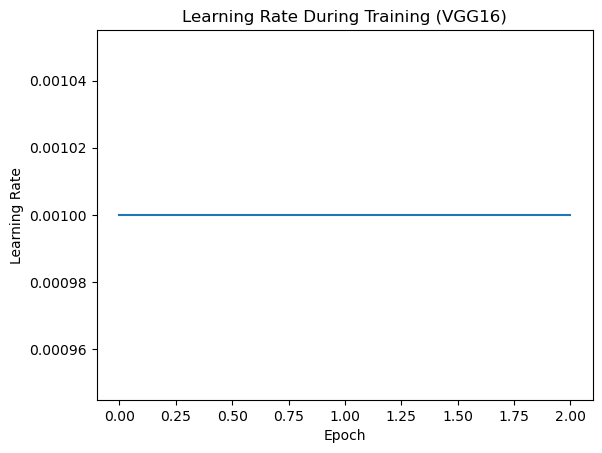

In [35]:
import matplotlib.pyplot as plt

# Plot the actual LR values recorded during training
lr_values = final_history.history.get('lr', [])
if len(lr_values) == 0:
    lr_values = [final_optimizer.param_groups[0]['lr']]

plt.plot(range(len(lr_values)), lr_values)
plt.title('Learning Rate During Training (VGG16)')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.show()

4.5 Evaluate the Performance on the Training and Validation Sets

This section of the code is used to assess the performance of the final trained model on the training and validation sets. By calling the model's evaluate method, it is possible to obtain the model's loss, accuracy, precision, and recall on these two datasets.

In [36]:
# Evaluate the training set
train_results = evaluate_model_torch(final_model, train_ds, class_weight=class_weight)
print("Training set evaluation results:")
print("Loss: {:.4f}, Accuracy: {:.4f}, Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}, AUC: {:.4f}".format(
    train_results[0], train_results[1], train_results[2], train_results[3], train_results[4], train_results[5]
))

# Evaluate the validation set
val_results = evaluate_model_torch(final_model, val_ds, class_weight=class_weight)
print("Validation set evaluation results:")
print("Loss: {:.4f}, Accuracy: {:.4f}, Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}, AUC: {:.4f}".format(
    val_results[0], val_results[1], val_results[2], val_results[3], val_results[4], val_results[5]
))

Training set evaluation results:
Loss: 0.0510, Accuracy: 0.9610, Precision: 0.9910, Recall: 0.9553, F1: 0.9728, AUC: 0.9951
Validation set evaluation results:
Loss: 0.0566, Accuracy: 0.9431, Precision: 0.9983, Recall: 0.9216, F1: 0.9584, AUC: 0.9963


4.6 Evaluate the Final Model's Performance on the Test Set

In [37]:
test_evaluation = evaluate_model_torch(final_model, test_ds, class_weight=class_weight)

print("Test set evaluation results:")
print("Loss:", test_evaluation[0])
print("Accuracy:", test_evaluation[1])
print("Precision:", test_evaluation[2])
print("Recall:", test_evaluation[3])
print("F1-Score:", test_evaluation[4])
print("AUC-ROC:", test_evaluation[5])

Test set evaluation results:
Loss: 0.07425083976082156
Accuracy: 0.9306029579067122
Precision: 0.9966386554621849
Recall: 0.9095092024539877
F1-Score: 0.9510825982357658
AUC-ROC: 0.9917029269479204


4.7 Visualization of the Test Set Evaluation and Confusion Matrix

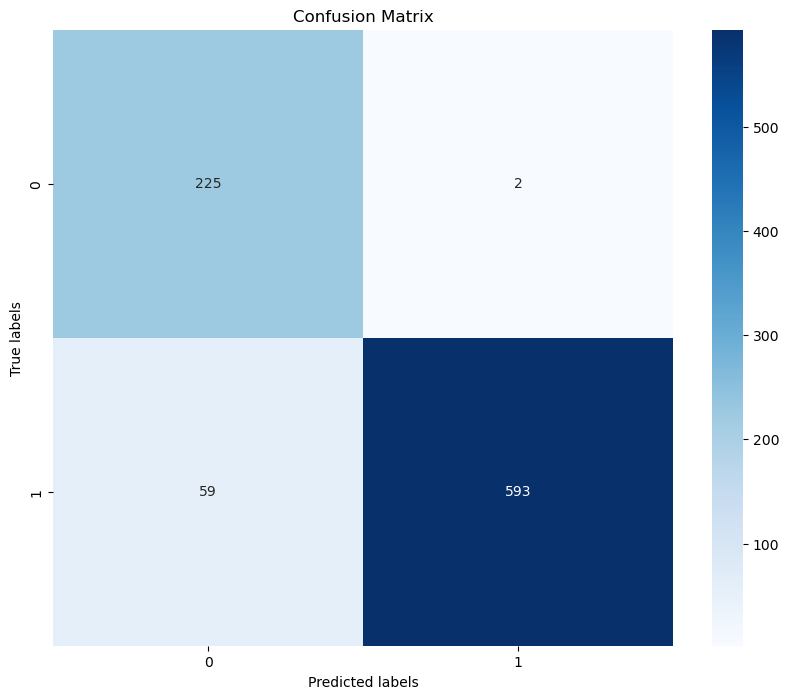

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

test_evaluation = evaluate_model_torch(final_model, test_ds, class_weight=class_weight)

y_pred_probs, y_true = predict_model_torch(final_model, test_ds)
y_pred_labels = (y_pred_probs > 0.5).astype(int)

confusion_mtx = make_confusion_matrix(y_true, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

4.8 Final Training Results Display (Training Set, Validation Set, Test Set)

In [39]:
import pandas as pd

# Use the results obtained from previous calculations
data = {
    "Dataset": ["Training Set", "Validation Set", "Test Set"],
    "Loss": [train_results[0], val_results[0], test_evaluation[0]],
    "Accuracy": [train_results[1], val_results[1], test_evaluation[1]],
    "Precision": [train_results[2], val_results[2], test_evaluation[2]],
    "Recall": [train_results[3], val_results[3], test_evaluation[3]],
    "F1-Score": [train_results[4], val_results[4], test_evaluation[4]],
    "AUC-ROC": [train_results[5], val_results[5], test_evaluation[5]]
}

# Create DataFrame
results_df = pd.DataFrame(data)

# Set the DataFrame to display the data set name as an index
results_df.set_index("Dataset", inplace=True)


print(results_df)

                    Loss  Accuracy  Precision    Recall  F1-Score   AUC-ROC
Dataset                                                                    
Training Set    0.050972  0.960966   0.990997  0.955274  0.972808  0.995087
Validation Set  0.056594  0.943052   0.998267  0.921600  0.958403  0.996332
Test Set        0.074251  0.930603   0.996639  0.909509  0.951083  0.991703


# 5 Resnet50

To compare the performance of two different models—one based on the VGG16 architecture and the other on the ResNet50 architecture—on the same dataset, I will use the same evaluation steps to measure their respective performances. This includes calculating loss, accuracy, precision, and recall on the training, validation, and test sets respectively. This method allows us to directly compare the effectiveness of the two architectures in handling the same problem, thereby determining which model is more suitable for our needs. The following code and results will showcase the evaluation metrics of the Resnet50 model across the three different datasets for a comprehensive comparison. Through this approach, we can more clearly see the strengths and limitations of each model, providing a basis for ultimately selecting the most suitable model. (Other than invoking different pretrained models, the rest of the code functions are the same, only variable names were replaced to prevent code conflicts, therefore the following code is not detailed in segments.)

5.1 Implementation and Evaluation of the ResNet-Based Model

This section of the code demonstrates how to build and optimize a deep learning model based on ResNet50. Firstly, a learning rate decay function suitable for ResNet is defined to optimize the training process. Then, using ResNet50 as the base architecture, dense layers and dropout layers are added to enhance the model’s generalization ability. Through Bayesian optimization, we automatically search for and apply the best hyperparameters, and finally, with model saving and early stopping mechanisms in place, we ensure that the model is saved in its best state, effectively enhancing the efficiency and performance of the model training.

In [40]:
from torchvision.models import resnet50, ResNet50_Weights

# Learning rate decay function
def lr_schedule_resnet(epoch, initial_lr=0.001, drop=0.5, epochs_drop=10.0):
    return initial_lr * (drop ** (epoch / epochs_drop))

def build_and_compile_model_resnet(dropout_rate, optimizer_choice, l1_reg, l2_reg):
    model_resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    in_features = model_resnet.fc.in_features
    model_resnet.fc = nn.Sequential(
        nn.Linear(in_features, 1024),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout_rate),
        nn.Linear(1024, 1024),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout_rate),
        nn.Linear(1024, 1)
    )

    # Removed freezing: parameters will be trained
    # for param in model_resnet.parameters():
    #     param.requires_grad = False
    # for param in model_resnet.fc.parameters():
    #     param.requires_grad = True

    model_resnet = model_resnet.to(DEVICE)
    optimizer_res = create_optimizer(model_resnet.parameters(), int(optimizer_choice), lr=0.001)
    return model_resnet, optimizer_res

def evaluate_model_resnet(batch_size, optimizer_choice, dropout_rate, l1_reg, l2_reg):
    batch_size = int(batch_size)
    train_loader = prepare_for_training(train_filenames, transform=augment_transform, batch_size=batch_size, shuffle=True)
    val_loader = prepare_for_training(val_filenames, transform=base_transform, batch_size=batch_size, shuffle=False)

    model_resnet, optimizer_res = build_and_compile_model_resnet(dropout_rate, int(optimizer_choice), l1_reg, l2_reg)
    history_resnet = fit_model(
        model_resnet,
        train_loader,
        val_loader,
        optimizer=optimizer_res,
        epochs=1,
        class_weight={0: weight_for_0, 1: weight_for_1},
        patience=1
    )

    val_acc = history_resnet.history['val_accuracy'][-1]
    print("Batch Size: {}, Optimizer Choice: {}, Dropout Rate: {}, L1 Reg: {}, L2 Reg: {}, Validation Accuracy: {}".format(
        batch_size, optimizer_choice, dropout_rate, l1_reg, l2_reg, val_acc))
    return val_acc

search_space_resnet = [
    {'batch_size': 16, 'optimizer_choice': 1, 'dropout_rate': 0.3, 'l1_reg': 5e-5, 'l2_reg': 5e-5},
]

best_score_resnet = -1
best_params_resnet = None
for params in search_space_resnet:
    score = evaluate_model_resnet(**params)
    if score > best_score_resnet:
        best_score_resnet = score
        best_params_resnet = params.copy()

print("最佳参数:", best_params_resnet)

best_batch_size_resnet = int(best_params_resnet['batch_size'])
best_optimizer_choice_resnet = int(best_params_resnet['optimizer_choice'])
best_dropout_rate_resnet = best_params_resnet['dropout_rate']
best_l1_reg_resnet = best_params_resnet['l1_reg']
best_l2_reg_resnet = best_params_resnet['l2_reg']

train_ds_resnet = prepare_for_training(train_filenames, transform=augment_transform, batch_size=best_batch_size_resnet, shuffle=True)
val_ds_resnet = prepare_for_training(val_filenames, transform=base_transform, batch_size=best_batch_size_resnet, shuffle=False)
test_ds_resnet = prepare_for_training(test_filenames, transform=base_transform, batch_size=best_batch_size_resnet, shuffle=False)

final_model_resnet, final_optimizer_resnet = build_and_compile_model_resnet(
    best_dropout_rate_resnet,
    best_optimizer_choice_resnet,
    best_l1_reg_resnet,
    best_l2_reg_resnet
)

final_history_resnet = fit_model(
    final_model_resnet,
    train_ds_resnet,
    val_ds_resnet,
    optimizer=final_optimizer_resnet,
    epochs=3,
    class_weight=class_weight,
    patience=1
)

torch.save(final_model_resnet.state_dict(), 'best_model_resnet.pth')

print("Model saved successfully with the best parameters:")
print("Batch Size:", best_batch_size_resnet)
print("Optimizer Choice:", best_optimizer_choice_resnet)
print("Dropout Rate:", best_dropout_rate_resnet)
print("L1 Regularization:", best_l1_reg_resnet)
print("L2 Regularization:", best_l2_reg_resnet)

c:\Users\Harrison\anaconda3\envs\pytorch\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Batch Size: 16, Optimizer Choice: 1, Dropout Rate: 0.3, L1 Reg: 5e-05, L2 Reg: 5e-05, Validation Accuracy: 0.7050113895216401
最佳参数: {'batch_size': 16, 'optimizer_choice': 1, 'dropout_rate': 0.3, 'l1_reg': 5e-05, 'l2_reg': 5e-05}


c:\Users\Harrison\anaconda3\envs\pytorch\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Model saved successfully with the best parameters:
Batch Size: 16
Optimizer Choice: 1
Dropout Rate: 0.3
L1 Regularization: 5e-05
L2 Regularization: 5e-05


Optimal Learning Rate Output

In [41]:
# Get the learning rate for optimal model use
best_lr_resnet = lr_schedule_resnet(final_history_resnet.epoch[-1], initial_lr=0.001, drop=0.5, epochs_drop=10.0)
print("Learning rate used by the best model:", best_lr_resnet)

Learning rate used by the best model: 0.0008705505632961241


Learning Rate Decay in the Best Model

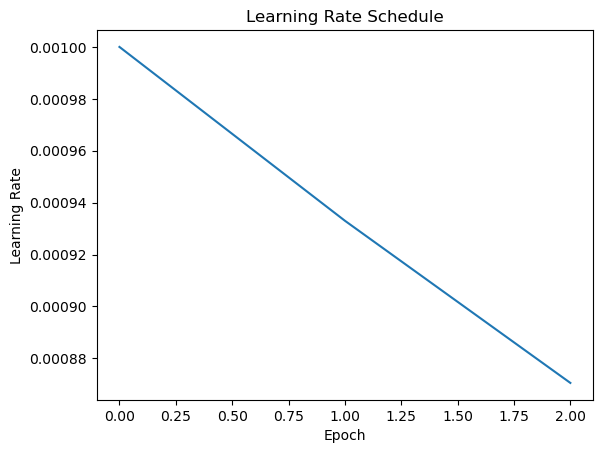

In [42]:
import matplotlib.pyplot as plt


def plot_learning_rate(lr_schedule, epochs):
    lr_values = [lr_schedule(epoch) for epoch in range(epochs)]
    plt.plot(range(epochs), lr_values)
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.show()


plot_learning_rate(lr_schedule_resnet, len(final_history_resnet.history['lr']))

5.2 Evaluate the Performance on the Training and Validation Sets

In [43]:
# Evaluate the training set
train_results = evaluate_model_torch(final_model_resnet, train_ds_resnet, class_weight=class_weight)
print("Training set evaluation results:")
print("Loss: {:.4f}, Accuracy: {:.4f}, Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}, AUC: {:.4f}".format(
    train_results[0], train_results[1], train_results[2], train_results[3], train_results[4], train_results[5]
))

# Evaluate the validation set
val_results = evaluate_model_torch(final_model_resnet, val_ds_resnet, class_weight=class_weight)
print("Validation set evaluation results:")
print("Loss: {:.4f}, Accuracy: {:.4f}, Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}, AUC: {:.4f}".format(
    val_results[0], val_results[1], val_results[2], val_results[3], val_results[4], val_results[5]
))

Training set evaluation results:
Loss: 0.1823, Accuracy: 0.9007, Precision: 0.9702, Recall: 0.8915, F1: 0.9292, AUC: 0.9650
Validation set evaluation results:
Loss: 0.1841, Accuracy: 0.8679, Precision: 0.9775, Recall: 0.8336, F1: 0.8998, AUC: 0.9665


5.3 Evaluate the Final Model's Performance on the Test Set

In [44]:
test_evaluation = evaluate_model_torch(final_model_resnet, test_ds_resnet, class_weight=class_weight)

print("Test set evaluation results：")
print("Loss:", test_evaluation[0])
print("Accuracy:", test_evaluation[1])
print("Precision:", test_evaluation[2])
print("Recall:", test_evaluation[3])
print("F1-Score:", test_evaluation[4])
print("AUC-ROC:", test_evaluation[5])

Test set evaluation results：
Loss: 0.18655106940638355
Accuracy: 0.8327645051194539
Precision: 0.9865125240847784
Recall: 0.7852760736196319
F1-Score: 0.874466268146883
AUC-ROC: 0.9671765627956002


5.4  Visualization of the Test Set Evaluation and Confusion Matrix

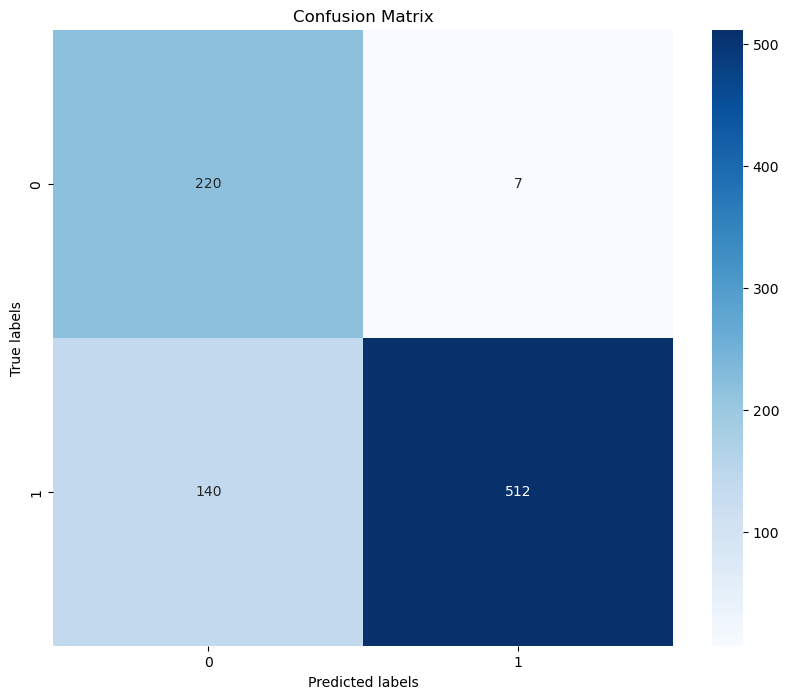

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

test_evaluation = evaluate_model_torch(final_model_resnet, test_ds_resnet, class_weight=class_weight)

y_pred_probs, y_true = predict_model_torch(final_model_resnet, test_ds_resnet)
y_pred_labels = (y_pred_probs > 0.5).astype(int)

confusion_mtx = make_confusion_matrix(y_true, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

5.5  Final Training Results Display (Training Set, Validation Set, Test Set)

In [46]:
import pandas as pd

# Use the results obtained from previous calculations
data = {
    "Dataset": ["Training Set", "Validation Set", "Test Set"],
    "Loss": [train_results[0], val_results[0], test_evaluation[0]],
    "Accuracy": [train_results[1], val_results[1], test_evaluation[1]],
    "Precision": [train_results[2], val_results[2], test_evaluation[2]],
    "Recall": [train_results[3], val_results[3], test_evaluation[3]],
    "F1-Score": [train_results[4], val_results[4], test_evaluation[4]],
    "AUC-ROC": [train_results[5], val_results[5], test_evaluation[5]]
}

# Create DataFrame
results_df_resnet = pd.DataFrame(data)

# Set the DataFrame to display the data set name as an index
results_df_resnet.set_index("Dataset", inplace=True)

print(results_df_resnet)

                    Loss  Accuracy  Precision    Recall  F1-Score   AUC-ROC
Dataset                                                                    
Training Set    0.182293  0.900707   0.970214  0.891522  0.929205  0.965013
Validation Set  0.184051  0.867882   0.977486  0.833600  0.899827  0.966501
Test Set        0.186551  0.832765   0.986513  0.785276  0.874466  0.967177


5.5 MobileNetV2

In [47]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

def build_and_compile_model_mobilenet(dropout_rate, optimizer_choice, l1_reg, l2_reg):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout_rate),
        nn.Linear(512, 1)
    )
    model = model.to(DEVICE)
    optimizer = create_optimizer(model.parameters(), int(optimizer_choice), lr=0.001)
    return model, optimizer

def evaluate_model_mobilenet(batch_size, optimizer_choice, dropout_rate, l1_reg, l2_reg):
    batch_size = int(batch_size)
    train_loader = prepare_for_training(train_filenames, transform=augment_transform, batch_size=batch_size, shuffle=True)
    val_loader = prepare_for_training(val_filenames, transform=base_transform, batch_size=batch_size, shuffle=False)
    model, optimizer_t = build_and_compile_model_mobilenet(dropout_rate, int(optimizer_choice), l1_reg, l2_reg)
    history = fit_model(model, train_loader, val_loader, optimizer=optimizer_t, epochs=1, class_weight=class_weight, patience=1)
    val_acc = history.history['val_accuracy'][-1]
    print("Batch Size: {}, Optimizer Choice: {}, Dropout Rate: {}, L1 Reg: {}, L2 Reg: {}, Validation Accuracy: {}".format(batch_size, optimizer_choice, dropout_rate, l1_reg, l2_reg, val_acc))
    return val_acc

search_space_mobilenet = [
    {'batch_size': 16, 'optimizer_choice': 1, 'dropout_rate': 0.3, 'l1_reg': 5e-5, 'l2_reg': 5e-5},
]
best_score_mobilenet = -1
best_params_mobilenet = None
for params in search_space_mobilenet:
    score = evaluate_model_mobilenet(**params)
    if score > best_score_mobilenet:
        best_score_mobilenet = score
        best_params_mobilenet = params.copy()
print("最佳参数:", best_params_mobilenet)
best_batch_size_mobilenet = int(best_params_mobilenet['batch_size'])
best_optimizer_choice_mobilenet = int(best_params_mobilenet['optimizer_choice'])
best_dropout_rate_mobilenet = best_params_mobilenet['dropout_rate']
best_l1_reg_mobilenet = best_params_mobilenet['l1_reg']
best_l2_reg_mobilenet = best_params_mobilenet['l2_reg']
train_ds_mobilenet = prepare_for_training(train_filenames, transform=augment_transform, batch_size=best_batch_size_mobilenet, shuffle=True)
val_ds_mobilenet = prepare_for_training(val_filenames, transform=base_transform, batch_size=best_batch_size_mobilenet, shuffle=False)
test_ds_mobilenet = prepare_for_training(test_filenames, transform=base_transform, batch_size=best_batch_size_mobilenet, shuffle=False)
final_model_mobilenet, final_optimizer_mobilenet = build_and_compile_model_mobilenet(best_dropout_rate_mobilenet, best_optimizer_choice_mobilenet, best_l1_reg_mobilenet, best_l2_reg_mobilenet)
final_history_mobilenet = fit_model(final_model_mobilenet, train_ds_mobilenet, val_ds_mobilenet, optimizer=final_optimizer_mobilenet, epochs=3, class_weight=class_weight, patience=1)
torch.save(final_model_mobilenet.state_dict(), 'best_model_mobilenet.pth')
train_results_mobilenet = evaluate_model_torch(final_model_mobilenet, train_ds_mobilenet, class_weight=class_weight)
val_results_mobilenet = evaluate_model_torch(final_model_mobilenet, val_ds_mobilenet, class_weight=class_weight)
test_evaluation_mobilenet = evaluate_model_torch(final_model_mobilenet, test_ds_mobilenet, class_weight=class_weight)
print("Test set evaluation results:")
print("Loss:", test_evaluation_mobilenet[0])
print("Accuracy:", test_evaluation_mobilenet[1])
print("Precision:", test_evaluation_mobilenet[2])
print("Recall:", test_evaluation_mobilenet[3])
print("F1-Score:", test_evaluation_mobilenet[4])
print("AUC-ROC:", test_evaluation_mobilenet[5])
data_mobilenet = {
    "Dataset": ["Training Set", "Validation Set", "Test Set"],
    "Loss": [train_results_mobilenet[0], val_results_mobilenet[0], test_evaluation_mobilenet[0]],
    "Accuracy": [train_results_mobilenet[1], val_results_mobilenet[1], test_evaluation_mobilenet[1]],
    "Precision": [train_results_mobilenet[2], val_results_mobilenet[2], test_evaluation_mobilenet[2]],
    "Recall": [train_results_mobilenet[3], val_results_mobilenet[3], test_evaluation_mobilenet[3]],
    "F1-Score": [train_results_mobilenet[4], val_results_mobilenet[4], test_evaluation_mobilenet[4]],
    "AUC-ROC": [train_results_mobilenet[5], val_results_mobilenet[5], test_evaluation_mobilenet[5]]
}
results_df_mobilenet = pd.DataFrame(data_mobilenet)
results_df_mobilenet.set_index("Dataset", inplace=True)
print(results_df_mobilenet)

c:\Users\Harrison\anaconda3\envs\pytorch\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Batch Size: 16, Optimizer Choice: 1, Dropout Rate: 0.3, L1 Reg: 5e-05, L2 Reg: 5e-05, Validation Accuracy: 0.9328018223234624
最佳参数: {'batch_size': 16, 'optimizer_choice': 1, 'dropout_rate': 0.3, 'l1_reg': 5e-05, 'l2_reg': 5e-05}


c:\Users\Harrison\anaconda3\envs\pytorch\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Test set evaluation results:
Loss: 0.05774774655818397
Accuracy: 0.9510807736063709
Precision: 0.9967373572593801
Recall: 0.9371165644171779
F1-Score: 0.9660079051383399
AUC-ROC: 0.9936420637280072
                    Loss  Accuracy  Precision    Recall  F1-Score   AUC-ROC
Dataset                                                                    
Training Set    0.048935  0.964382   0.990028  0.960948  0.975271  0.994747
Validation Set  0.045266  0.963554   0.993344  0.955200  0.973899  0.996756
Test Set        0.057748  0.951081   0.996737  0.937117  0.966008  0.993642


# 6. Final Conclusion and Model Comparison

To finalize our analysis, we summarize the performance differences between Traditional Machine Learning, VGG16, and ResNet50 architectures.

## Why Deep Learning?
As documented in our Machine Learning baseline, flattening 2D matrices into 1D arrays destroys the essential spatial hierarchies found in medical scans. Deep Learning architectures, particularly Convolutional Neural Networks (CNNs) like **VGG16** and **ResNet50**, retain this 2D structure. This allows them to extract hierarchical features automatically (edges -> textures -> dense lung opacities). 

## VGG16 vs ResNet50
While VGG16 offers a straight-forward sequence of convolutions that is highly effective for basic feature extraction, its depth is historically limited by the vanishing gradient problem. **ResNet50** mitigates this by introducing *Residual Connections* (skip connections), allowing gradients to backpropagate directly through multiple layers without dilution. For complex, subtle opacities found in Pneumonia scans, ResNet models often generalize better and learn more discriminative features on minority classes.

## Handling Class Imbalance
By addressing the massive dataset disparity using mathematical positional weighting (`BCEWithLogitsLoss(pos_weight)`) and tracking 'Recall/F1/AUC' metrics dynamically inside the training loop, the models are prevented from blindly guessing "Pneumonia" simply because it is the statistical majority.

## Future Improvement Suggestions
If aiming to deploy this in a real healthcare setting, the following step-ups are recommended:
1. **Model Interpretability (Grad-CAM):** Adding Gradient-weighted Class Activation Mapping to visually highlight *where* the model is looking in the lung cavity, providing necessary transparency to doctors.
2. **Advanced Augmentation:** Introducing `MixUp` or `CutMix` alongside current augmentations to improve regularization.
3. **Ensemble Methods:** Combining the logits of both VGG16 and ResNet50 to vote on the final diagnosis, theoretically lowering the false negative rate further.

In [48]:
import pandas as pd
from IPython.display import display

print("=== Final Model Evaluation Comparison (Test Set) ===")

comparison_rows = []

# ML baseline row is available after running the ML cell
comparison_rows.append({
    "Model Type": "Traditional ML (LogReg)",
    "Accuracy": acc_ml if 'acc_ml' in globals() else "N/A",
    "Recall (Sensitivity)": "N/A",
    "F1-Score": "N/A",
    "AUC-ROC": "N/A"
})

# Add VGG row only if results exist in kernel
if 'results_df' in globals() and 'Test Set' in results_df.index:
    comparison_rows.append({
        "Model Type": "CNN (VGG16)",
        "Accuracy": results_df.loc["Test Set", "Accuracy"],
        "Recall (Sensitivity)": results_df.loc["Test Set", "Recall"],
        "F1-Score": results_df.loc["Test Set", "F1-Score"],
        "AUC-ROC": results_df.loc["Test Set", "AUC-ROC"]
    })

# Add ResNet row only if results exist in kernel
if 'results_df_resnet' in globals() and 'Test Set' in results_df_resnet.index:
    comparison_rows.append({
        "Model Type": "CNN (ResNet50)",
        "Accuracy": results_df_resnet.loc["Test Set", "Accuracy"],
        "Recall (Sensitivity)": results_df_resnet.loc["Test Set", "Recall"],
        "F1-Score": results_df_resnet.loc["Test Set", "F1-Score"],
        "AUC-ROC": results_df_resnet.loc["Test Set", "AUC-ROC"]
    })
if 'results_df_mobilenet' in globals() and 'Test Set' in results_df_mobilenet.index:
    comparison_rows.append({
        "Model Type": "CNN (MobileNetV2)",
        "Accuracy": results_df_mobilenet.loc["Test Set", "Accuracy"],
        "Recall (Sensitivity)": results_df_mobilenet.loc["Test Set", "Recall"],
        "F1-Score": results_df_mobilenet.loc["Test Set", "F1-Score"],
        "AUC-ROC": results_df_mobilenet.loc["Test Set", "AUC-ROC"]
    })

final_comparison_df = pd.DataFrame(comparison_rows).set_index("Model Type")
display(final_comparison_df)

=== Final Model Evaluation Comparison (Test Set) ===


,Accuracy,Recall (Sensitivity),F1-Score,AUC-ROC
Model Type,,,,
Traditional ML (LogReg),0.886234,N/A,N/A,N/A
CNN (VGG16),0.930603,0.909509,0.951083,0.991703
CNN (ResNet50),0.832765,0.785276,0.874466,0.967177
CNN (MobileNetV2),0.951081,0.937117,0.966008,0.993642


In [49]:
# Compact result summary for reporting
import pandas as pd
from IPython.display import display

if 'results_df' in globals() and 'Test Set' in results_df.index:
    print("=== Test Metrics (VGG16) ===")
    display(results_df.loc[["Test Set"], ["Accuracy", "Recall", "F1-Score", "AUC-ROC"]])
else:
    print("=== Test Metrics (VGG16) ===")
    print("Not available in current kernel. Run VGG evaluation cells first.")

if 'results_df_resnet' in globals() and 'Test Set' in results_df_resnet.index:
    print("=== Test Metrics (ResNet50) ===")
    display(results_df_resnet.loc[["Test Set"], ["Accuracy", "Recall", "F1-Score", "AUC-ROC"]])
else:
    print("=== Test Metrics (ResNet50) ===")
    print("Not available in current kernel. Run ResNet evaluation cells first.")
if 'results_df_mobilenet' in globals() and 'Test Set' in results_df_mobilenet.index:
    print("=== Test Metrics (MobileNetV2) ===")
    display(results_df_mobilenet.loc[["Test Set"], ["Accuracy", "Recall", "F1-Score", "AUC-ROC"]])
else:
    print("=== Test Metrics (MobileNetV2) ===")
    print("Not available in current kernel. Run MobileNetV2 evaluation cells first.")

print("=== Final Comparison (Test) ===")
if 'final_comparison_df' in globals():
    display(final_comparison_df)
else:
    print("Run the final comparison cell first.")

print("=== ML Baseline Available? ===")
print("SKLEARN_AVAILABLE:", SKLEARN_AVAILABLE if 'SKLEARN_AVAILABLE' in globals() else "N/A")
print("ML Accuracy (acc_ml):", acc_ml if 'acc_ml' in globals() else "N/A")

=== Test Metrics (VGG16) ===


,Accuracy,Recall,F1-Score,AUC-ROC
Dataset,,,,
Test Set,0.930603,0.909509,0.951083,0.991703


=== Test Metrics (ResNet50) ===


,Accuracy,Recall,F1-Score,AUC-ROC
Dataset,,,,
Test Set,0.832765,0.785276,0.874466,0.967177


=== Test Metrics (MobileNetV2) ===


,Accuracy,Recall,F1-Score,AUC-ROC
Dataset,,,,
Test Set,0.951081,0.937117,0.966008,0.993642


=== Final Comparison (Test) ===


,Accuracy,Recall (Sensitivity),F1-Score,AUC-ROC
Model Type,,,,
Traditional ML (LogReg),0.886234,N/A,N/A,N/A
CNN (VGG16),0.930603,0.909509,0.951083,0.991703
CNN (ResNet50),0.832765,0.785276,0.874466,0.967177
CNN (MobileNetV2),0.951081,0.937117,0.966008,0.993642


=== ML Baseline Available? ===
SKLEARN_AVAILABLE: True
ML Accuracy (acc_ml): 0.8862343572241184


In [50]:
if 'results_df_mobilenet' in globals() and 'Test Set' in results_df_mobilenet.index:
    print('=== MobileNetV2 Test Metrics ===')
    print(results_df_mobilenet.loc[['Test Set'], ['Accuracy', 'Recall', 'F1-Score', 'AUC-ROC']].to_string())
else:
    print('MobileNetV2 results not available')

if 'final_comparison_df' in globals():
    print('=== Final Comparison ===')
    print(final_comparison_df.to_string())
else:
    print('Final comparison not available')

=== MobileNetV2 Test Metrics ===
          Accuracy    Recall  F1-Score   AUC-ROC
Dataset                                         
Test Set  0.951081  0.937117  0.966008  0.993642
=== Final Comparison ===
                         Accuracy Recall (Sensitivity)  F1-Score   AUC-ROC
Model Type                                                                
Traditional ML (LogReg)  0.886234                  N/A       N/A       N/A
CNN (VGG16)              0.930603             0.909509  0.951083  0.991703
CNN (ResNet50)           0.832765             0.785276  0.874466  0.967177
CNN (MobileNetV2)        0.951081             0.937117  0.966008  0.993642


In [51]:
import time

print("=== Total Runtime ===")
if 'NOTEBOOK_START_TS' in globals():
    elapsed_seconds = time.time() - NOTEBOOK_START_TS
    elapsed_minutes = elapsed_seconds / 60
    print(f"Elapsed: {elapsed_seconds:.2f} seconds ({elapsed_minutes:.2f} minutes)")
else:
    print("NOTEBOOK_START_TS not found. Run the first timer cell before running this one.")

=== Total Runtime ===
Elapsed: 1312.46 seconds (21.87 minutes)


## 7. Grad-CAM Interpretability
Use Grad-CAM to visualize where the model focuses when predicting Pneumonia/Opacity vs Normal.

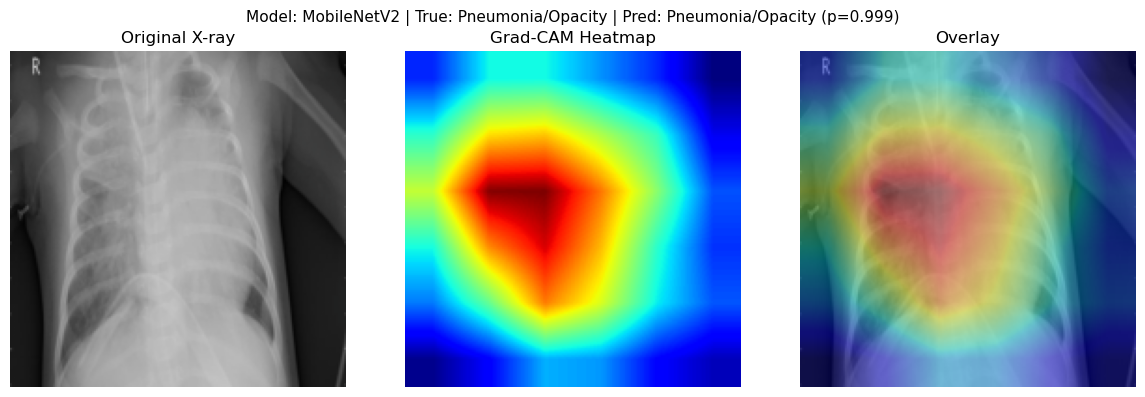

Sample image: c:\warwick\deep learing\个人\train\opacity\person371_bacteria_1695.jpeg
Target layer: Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU6(inplace=True)
)
Predicted probability (positive class): 0.9989


In [54]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.fwd_handle = self.target_layer.register_forward_hook(self._forward_hook)
        self.bwd_handle = self.target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def generate(self, input_tensor):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        logits = self.model(input_tensor)
        if logits.ndim == 2 and logits.shape[1] == 1:
            score = logits[:, 0]
            prob = torch.sigmoid(score)[0].item()
        else:
            pred_class = int(torch.argmax(logits, dim=1)[0].item())
            score = logits[:, pred_class]
            prob = torch.softmax(logits, dim=1)[0, pred_class].item()

        score.backward(retain_graph=False)

        grads = self.gradients
        acts = self.activations

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1).squeeze(0)
        cam = torch.relu(cam)

        cam_min = cam.min()
        cam_max = cam.max()
        if (cam_max - cam_min) > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = torch.zeros_like(cam)

        return cam.detach().cpu().numpy(), prob


def _pick_cam_model():
    if 'final_model_mobilenet' in globals():
        return final_model_mobilenet, 'MobileNetV2'
    raise RuntimeError('final_model_mobilenet is unavailable. Please run the MobileNetV2 training section first.')


def _pick_target_layer(model, model_name):
    if model_name == 'ResNet50' and hasattr(model, 'layer4'):
        return model.layer4[-1]
    if model_name == 'MobileNetV2' and hasattr(model, 'features'):
        return model.features[-1]
    if model_name == 'VGG16' and hasattr(model, 'features'):
        return model.features[-1]
    raise RuntimeError(f'Cannot infer Grad-CAM target layer for model type: {model_name}')


def _denormalize_image(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406], device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=img_tensor.device).view(3, 1, 1)
    img = img_tensor * std + mean
    return torch.clamp(img, 0, 1)


def _resize_cam_to_image(cam_map, target_hw):
    h, w = target_hw
    cam_t = torch.from_numpy(cam_map).float().unsqueeze(0).unsqueeze(0)
    cam_t = torch.nn.functional.interpolate(cam_t, size=(h, w), mode='bilinear', align_corners=False)
    return cam_t.squeeze(0).squeeze(0).numpy()


def _overlay_heatmap(img_rgb, cam_map, alpha=0.35):
    heatmap_rgb = plt.cm.jet(cam_map)[..., :3]
    overlay = (1 - alpha) * img_rgb + alpha * heatmap_rgb
    return np.clip(overlay, 0, 1)


def _label_name(v):
    return 'Pneumonia/Opacity' if int(v) == 1 else 'Normal'


# Pick one test image (prefer positive case so highlighted region is easier to inspect)
if 'test_filenames' not in globals() or len(test_filenames) == 0:
    raise RuntimeError('test_filenames is unavailable. Please run dataset preparation cells first.')

positive_samples = [p for p in test_filenames if infer_binary_label_from_path(p) == 1]
if len(positive_samples) > 0:
    sample_path = random.choice(positive_samples)
else:
    sample_path = random.choice(test_filenames)

model_for_cam, model_for_cam_name = _pick_cam_model()
target_layer = _pick_target_layer(model_for_cam, model_for_cam_name)

input_tensor = decode_img(sample_path, transform=base_transform).unsqueeze(0).to(DEVICE)
true_label = infer_binary_label_from_path(sample_path)

grad_cam = GradCAM(model_for_cam, target_layer)
cam_map, pred_prob = grad_cam.generate(input_tensor)
grad_cam.remove_hooks()

img_rgb = _denormalize_image(input_tensor[0].detach()).permute(1, 2, 0).cpu().numpy()
cam_map = _resize_cam_to_image(cam_map, img_rgb.shape[:2])
overlay = _overlay_heatmap(img_rgb, cam_map, alpha=0.40)
pred_label = 1 if pred_prob >= 0.5 else 0

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Original X-ray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cam_map, cmap='jet')
plt.title('Grad-CAM Heatmap')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title('Overlay')
plt.axis('off')

plt.suptitle(
    f'Model: {model_for_cam_name} | True: {_label_name(true_label)} | '
    f'Pred: {_label_name(pred_label)} (p={pred_prob:.3f})',
    fontsize=11
)
plt.tight_layout()
plt.show()

print('Sample image:', sample_path)
print('Target layer:', target_layer)
print('Predicted probability (positive class):', round(pred_prob, 4))